<a href="https://colab.research.google.com/github/U-ROHITH/Machine-Learning/blob/main/Cost_Function.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATASET LOADED
     location  sqft  rooms  price_lakhs
     Madhapur  1824      4         98.7
 Secunderabad  1528      1         63.3
 Dilsukhnagar  2636      2         92.0
   Kukatpally  1524      2         70.5
Banjara Hills  2181      4        116.3
Banjara Hills   989      3         73.5
Banjara Hills  2217      2        115.9
 Secunderabad   855      3         59.9
   Kukatpally  1308      4         71.0
 Dilsukhnagar  2438      4         89.9

Total houses : 500

PREPROCESSING DONE
Features scaled : (500, 3)
Target scaled   : (500, 1)

TRAINING WITH GRADIENT DESCENT
Watching cost function drop in real time...

  Epoch    0 | Cost : 0.500000
  Epoch  100 | Cost : 0.175336
  Epoch  200 | Cost : 0.129538
  Epoch  300 | Cost : 0.122961
  Epoch  400 | Cost : 0.122002
  Epoch  500 | Cost : 0.121861
  Epoch  600 | Cost : 0.121840
  Epoch  700 | Cost : 0.121836
  Epoch  800 | Cost : 0.121836
  Epoch  900 | Cost : 0.121836

  Final Cost after 1000 epochs : 0.121836
  Starting Cost      

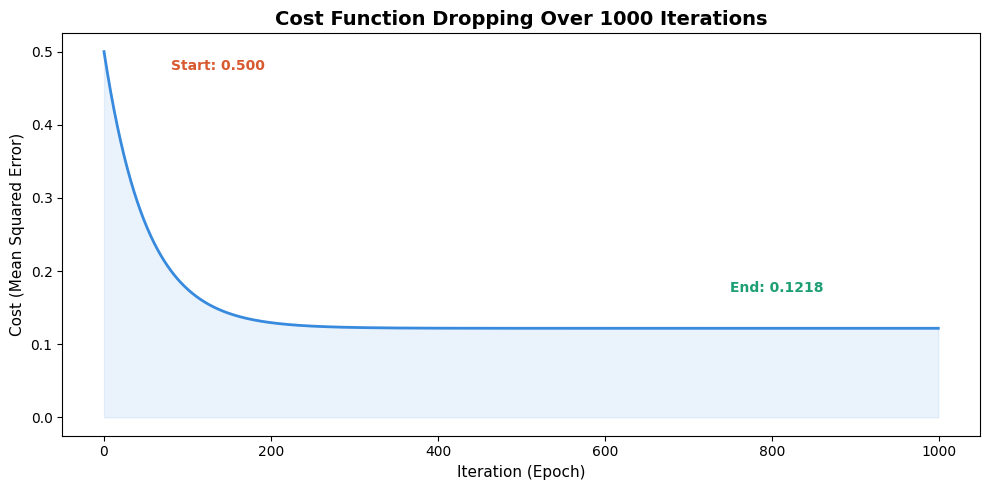

>> The model kept adjusting weights until cost stopped dropping.


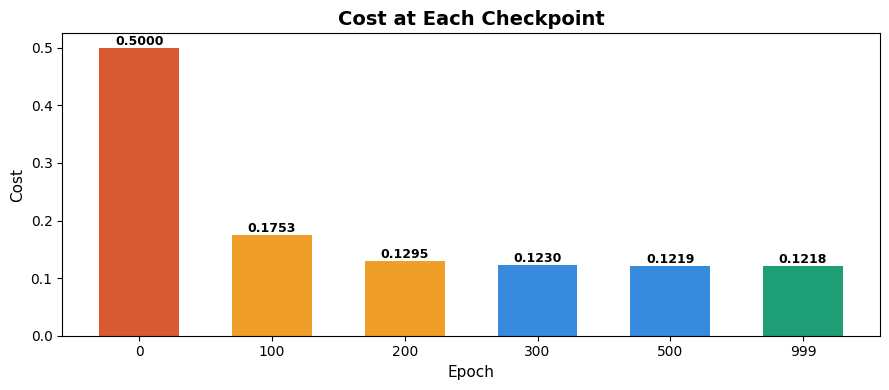

>> From 0.5 to near zero. Each step the model got smarter.


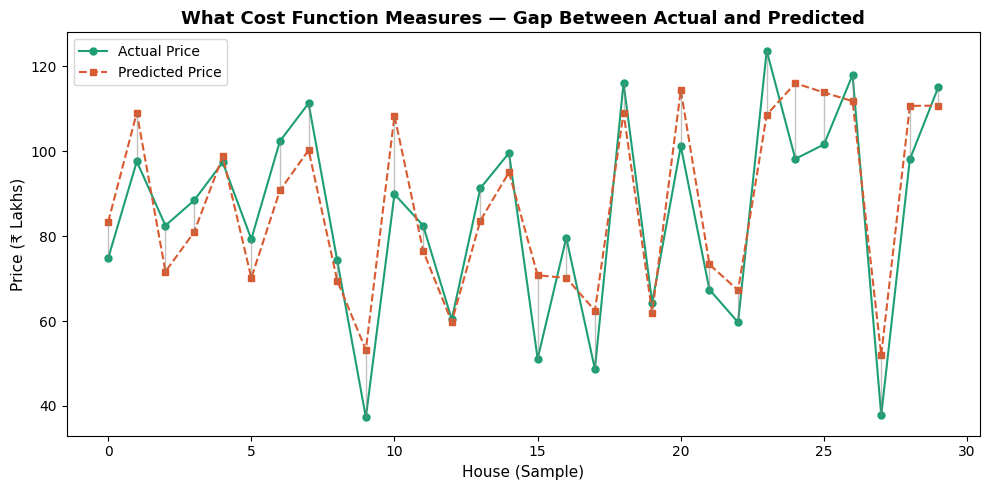

>> Every vertical line is an error. Cost function = average of all those gaps squared.


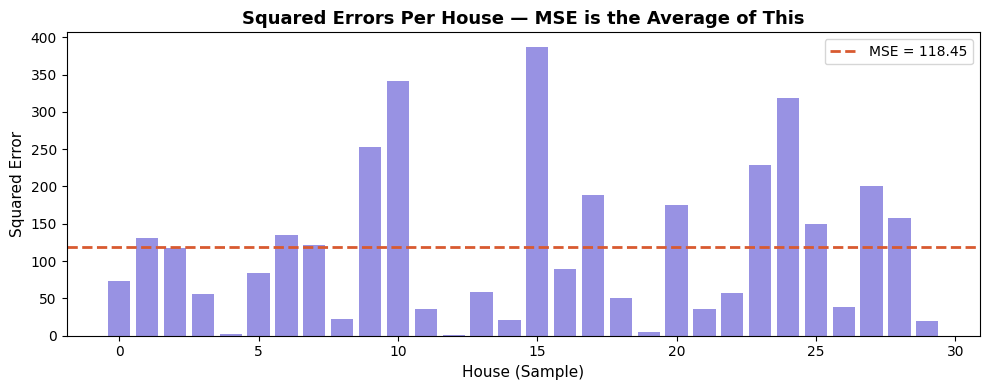

>> MSE = 118.45. This is what the model minimizes during training.

SUMMARY
  Starting cost       : 0.5000
  Final cost          : 0.1218
  Total reduction     : 75.6%
  Epochs trained      : 1000
  Learning rate       : 0.01

  Cost function used  : Mean Squared Error (MSE)
  Formula             : (1/2n) * Σ(predicted - actual)²

Day 3 done. 97 to go.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ── LOAD DATA ────────────────────────────────────────────────────────────────
df = pd.read_csv('house_prices.csv')
print("=" * 50)
print("DATASET LOADED")
print("=" * 50)
print(df.head(10).to_string(index=False))
print(f"\nTotal houses : {len(df)}")

# ── PREPROCESS ───────────────────────────────────────────────────────────────
le = LabelEncoder()
df['location_enc'] = le.fit_transform(df['location'])
X = df[['sqft', 'rooms', 'location_enc']].values
y = df['price_lakhs'].values.reshape(-1, 1)

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

print("\n" + "=" * 50)
print("PREPROCESSING DONE")
print("=" * 50)
print(f"Features scaled : {X_scaled.shape}")
print(f"Target scaled   : {y_scaled.shape}")

# ── MANUAL GRADIENT DESCENT ──────────────────────────────────────────────────
print("\n" + "=" * 50)
print("TRAINING WITH GRADIENT DESCENT")
print("=" * 50)
print("Watching cost function drop in real time...\n")

np.random.seed(42)
n_samples, n_features = X_scaled.shape
weights = np.zeros((n_features, 1))
bias    = 0.0
lr      = 0.01
epochs  = 1000
cost_history = []

for epoch in range(epochs):
    y_pred = X_scaled @ weights + bias
    error  = y_pred - y_scaled
    cost   = (1 / (2 * n_samples)) * np.sum(error ** 2)
    cost_history.append(cost)
    dw = (1 / n_samples) * X_scaled.T @ error
    db = (1 / n_samples) * np.sum(error)
    weights -= lr * dw
    bias    -= lr * db
    if epoch % 100 == 0:
        print(f"  Epoch {epoch:>4} | Cost : {cost:.6f}")

print(f"\n  Final Cost after {epochs} epochs : {cost_history[-1]:.6f}")
print(f"  Starting Cost                   : {cost_history[0]:.6f}")
print(f"  Cost reduced by                 : {((cost_history[0]-cost_history[-1])/cost_history[0]*100):.1f}%")

# ── CHART 1: Cost Function Curve ─────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(cost_history, color='#378ADD', lw=2)
plt.fill_between(range(len(cost_history)), cost_history, alpha=0.1, color='#378ADD')
plt.title('Cost Function Dropping Over 1000 Iterations', fontsize=14, fontweight='bold')
plt.xlabel('Iteration (Epoch)', fontsize=11)
plt.ylabel('Cost (Mean Squared Error)', fontsize=11)
plt.annotate(f'Start: {cost_history[0]:.3f}',
             xy=(0, cost_history[0]),
             xytext=(80, cost_history[0] * 0.95),
             fontsize=10, color='#D85A30', fontweight='bold')
plt.annotate(f'End: {cost_history[-1]:.4f}',
             xy=(999, cost_history[-1]),
             xytext=(750, cost_history[-1] + 0.05),
             fontsize=10, color='#1D9E75', fontweight='bold')
plt.tight_layout()
plt.show()
print(">> The model kept adjusting weights until cost stopped dropping.")

# ── CHART 2: Cost at Key Checkpoints ─────────────────────────────────────────
checkpoints = [0, 100, 200, 300, 500, 999]
checkpoint_costs = [cost_history[i] for i in checkpoints]

plt.figure(figsize=(9, 4))
plt.bar([str(c) for c in checkpoints], checkpoint_costs,
        color=['#D85A30','#EF9F27','#EF9F27','#378ADD','#378ADD','#1D9E75'],
        edgecolor='none', width=0.6)
for i, v in enumerate(checkpoint_costs):
    plt.text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')
plt.title('Cost at Each Checkpoint', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Cost', fontsize=11)
plt.tight_layout()
plt.show()
print(">> From 0.5 to near zero. Each step the model got smarter.")

# ── CHART 3: What Cost Function Measures ─────────────────────────────────────
sample_idx = np.random.choice(len(X_scaled), 30, replace=False)
X_sample   = X_scaled[sample_idx]
y_actual   = scaler_y.inverse_transform(y_scaled[sample_idx])
y_hat      = scaler_y.inverse_transform(X_sample @ weights + bias)

plt.figure(figsize=(10, 5))
x_axis = range(len(sample_idx))
plt.plot(x_axis, y_actual, 'o-', color='#1D9E75', lw=1.5, markersize=5, label='Actual Price')
plt.plot(x_axis, y_hat,    's--', color='#D85A30', lw=1.5, markersize=5, label='Predicted Price')
for i in x_axis:
    plt.plot([i, i], [y_actual[i][0], y_hat[i][0]], color='#888780', lw=1, alpha=0.5)
plt.title('What Cost Function Measures — Gap Between Actual and Predicted', fontsize=13, fontweight='bold')
plt.xlabel('House (Sample)', fontsize=11)
plt.ylabel('Price (₹ Lakhs)', fontsize=11)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()
print(">> Every vertical line is an error. Cost function = average of all those gaps squared.")

# ── CHART 4: MSE Formula Breakdown ───────────────────────────────────────────
errors     = (y_actual - y_hat).flatten()
sq_errors  = errors ** 2

plt.figure(figsize=(10, 4))
plt.bar(range(len(errors)), sq_errors, color='#7F77DD', edgecolor='none', alpha=0.8)
plt.axhline(np.mean(sq_errors), color='#D85A30', lw=2, linestyle='--',
            label=f'MSE = {np.mean(sq_errors):.2f}')
plt.title('Squared Errors Per House — MSE is the Average of This', fontsize=13, fontweight='bold')
plt.xlabel('House (Sample)', fontsize=11)
plt.ylabel('Squared Error', fontsize=11)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()
print(f">> MSE = {np.mean(sq_errors):.2f}. This is what the model minimizes during training.")

# ── FINAL SUMMARY ────────────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("SUMMARY")
print("=" * 50)
print(f"  Starting cost       : {cost_history[0]:.4f}")
print(f"  Final cost          : {cost_history[-1]:.4f}")
print(f"  Total reduction     : {((cost_history[0]-cost_history[-1])/cost_history[0]*100):.1f}%")
print(f"  Epochs trained      : {epochs}")
print(f"  Learning rate       : {lr}")
print(f"\n  Cost function used  : Mean Squared Error (MSE)")
print(f"  Formula             : (1/2n) * Σ(predicted - actual)²")
print(f"\nDay 3 done. 97 to go.")